# Assignment B: AI-Generated Knit Swatch Preview

Turn a structured knitting specification (stitch, hex color, yarn weight, fiber) into a **macro fabric preview**. Live mode calls OpenAI DALL·E 3. If the API key is missing, `OFFLINE_MODE` is on, or the network fails, Pillow synthesizes a stitch-distinct placeholder so the notebook never crashes.

Run top to bottom. Optional keys in the repo-root `.env` (gitignored):

- `OPENAI_API_KEY` — photorealistic generation
- `RAVELRY_ACCESS_KEY` / `RAVELRY_PERSONAL_KEY` — real pattern photo comparison
- `OFFLINE_MODE=true` — force procedural textures even when a key is present

Disk cache: `./swatch_cache/{sha256}.png`.


In [114]:
%pip install openai pillow matplotlib requests python-dotenv --quiet


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [115]:
import openai
import PIL
import matplotlib
import requests
from dotenv import load_dotenv

print("✅ Everything is working!")

✅ Everything is working!


## Cell 1 — Environment setup and dependencies

Load secrets without printing them. Create the cache directory. Decide live vs offline before any generation call.


In [116]:
import hashlib
import io
import json
import math
import os
import random
import time
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Optional
from urllib.parse import quote_plus

import matplotlib.pyplot as plt
import requests
from PIL import Image, ImageChops, ImageDraw, ImageEnhance, ImageFilter, ImageFont

try:
    from dotenv import load_dotenv
except ImportError:
    load_dotenv = None  # type: ignore

try:
    from openai import OpenAI
except ImportError:
    OpenAI = None  # type: ignore


def _env_flag(name: str, default: bool = False) -> bool:
    raw = os.environ.get(name)
    if raw is None:
        return default
    value = raw.strip().lower()
    if value in ("1", "true", "yes", "on"):
        return True
    if value in ("0", "false", "no", "off"):
        return False
    return default


def _load_env_file() -> Optional[Path]:
    if load_dotenv is None:
        return None
    cwd = Path.cwd()
    repo = cwd
    for path in (cwd, *cwd.parents):
        if (path / ".git").exists() or (path / ".env.example").exists():
            repo = path
            break
    env_path = repo / ".env"
    if not env_path.is_file():
        return None
    load_dotenv(env_path, override=True)
    return env_path.resolve()


ENV_FILE = _load_env_file()
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY", "").strip()
RAVELRY_ACCESS_KEY = os.getenv("RAVELRY_ACCESS_KEY", "").strip()
RAVELRY_PERSONAL_KEY = os.getenv("RAVELRY_PERSONAL_KEY", "").strip()
OFFLINE_MODE = _env_flag("OFFLINE_MODE", default=False) or not bool(OPENAI_API_KEY)
CACHE_DIR = Path("./swatch_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)
USE_OPENAI = (not OFFLINE_MODE) and bool(OPENAI_API_KEY) and OpenAI is not None

env_note = f"loaded {ENV_FILE}" if ENV_FILE else "no .env file"
print(
    f"OFFLINE_MODE={OFFLINE_MODE} | {env_note} | "
    f"OpenAI key={bool(OPENAI_API_KEY)} | openai package={OpenAI is not None} | "
    f"live images={USE_OPENAI} | Ravelry keys={bool(RAVELRY_ACCESS_KEY and RAVELRY_PERSONAL_KEY)} | "
    f"cache={CACHE_DIR.resolve()}"
)
if USE_OPENAI:
    print("Live DALL-E 3 is on: uncached generate_swatch calls will hit the Images API.")
else:
    print("Using procedural Pillow textures (no Images API calls).")


OFFLINE_MODE=False | loaded E:\brdgeai\.env | OpenAI key=True | openai package=True | live images=True | Ravelry keys=True | cache=E:\brdgeai\assignment-b\swatch_cache
Live DALL-E 3 is on: uncached generate_swatch calls will hit the Images API.


## Cell 2 — Domain reference and prompt engineering

Craft Yarn Council–aligned language is locked in dictionaries. `build_prompt` is the only place those phrases become an image prompt, so stitch geometry stays deterministic and auditable.


In [117]:
@dataclass
class SwatchSpec:
    stitch_type: str  # "stockinette", "garter", "rib", "seed", "cable", "lace"
    colour_name: str  # e.g., "royal purple", "sage green"
    colour_hex: str  # e.g., "#5B3E96"
    weight_category: str  # "lace", "fingering", "dk", "worsted", "bulky", "super_bulky"
    fibre_content: str  # "100% wool", "100% cotton", "mohair", "alpaca blend"


STITCH_STRUCTURAL_DESCRIPTIONS = {
    "stockinette": (
        "smooth, uniform, interlocking 'V' shaped knit loops stacked in neat vertical "
        "columns on a flat knit jersey face."
    ),
    "garter": (
        "dense horizontal wavy ridges and purl bumps running across the fabric with no "
        "visible vertical 'V' columns, identical on front and back."
    ),
    "rib": (
        "pronounced alternating 2x2 vertical columns of raised knit stitches and recessed "
        "purl valleys, forming an elastic corrugated accordion texture."
    ),
    "seed": (
        "an all-over speckled, pebbled checkerboard texture created by alternating single "
        "knit and purl stitches every column and row, non-directional."
    ),
    "cable": (
        "prominent, thick, 3D raised twisted rope-like braided cords crossing over each "
        "other with deep shadowed recessed valleys."
    ),
    "lace": (
        "delicate openwork fabric with regularly spaced eyelet holes, yarn-overs, and open "
        "geometric perforated mesh motifs."
    ),
}

WEIGHT_DESCRIPTIONS = {
    "lace": "ultra-fine, delicate thread-like stitches with sheer openness",
    "fingering": "fine, crisp, tightly defined small stitches",
    "dk": "medium-light balanced stitch definition",
    "worsted": "standard medium-weight, chunky defined yarn plies",
    "bulky": "thick, heavy rope-like yarns with prominent stitch definition",
    "super_bulky": "massive, roving-style giant knit stitches",
}

FIBRE_DESCRIPTIONS = {
    "100% wool": "matte, organic wool with a natural plied yarn twist and subtle surface fiber halo",
    "100% cotton": "clean, smooth, dense plant fiber with crisp stitch edges and zero fuzzy halo",
    "mohair": "airy, cloud-like fabric with an ethereal, long-fiber brushed halo obscuring the stitch base",
    "alpaca blend": "silky, heavy drape with soft subtle luster and slight surface fuzz",
}

WEIGHT_SCALE = {
    "lace": 0.55,
    "fingering": 0.70,
    "dk": 0.85,
    "worsted": 1.00,
    "bulky": 1.35,
    "super_bulky": 1.75,
}


def build_prompt(spec: SwatchSpec) -> str:
    stitch_key = spec.stitch_type.strip().lower()
    weight_key = spec.weight_category.strip().lower().replace(" ", "_")
    fibre_key = spec.fibre_content.strip()
    structure = STITCH_STRUCTURAL_DESCRIPTIONS.get(stitch_key, spec.stitch_type)
    weight = WEIGHT_DESCRIPTIONS.get(weight_key, spec.weight_category)
    fibre = FIBRE_DESCRIPTIONS.get(fibre_key, spec.fibre_content)
    hex_code = spec.colour_hex.strip().upper()
    if not hex_code.startswith("#"):
        hex_code = "#" + hex_code

    return (
        "Photorealistic extreme macro photograph, 1:1 close-up of a 10x10cm knitted fabric "
        f"swatch, flat lay, needlecraft textile texture filling the entire frame. "
        f"Stitch pattern: {stitch_key}: {structure} "
        f"Yarn colour: {spec.colour_name} dyed to exact hex {hex_code}, saturated and even, "
        "no variegation, no staining. "
        f"Yarn weight: {weight_key}: {weight}. "
        f"Fiber: {fibre}. "
        "Soft directional natural window light from the upper left, catching highlights on "
        "raised knit loops and casting crisp micro-shadows into purl valleys, cable twists, "
        "and eyelet holes. Shallow depth of field typical of a 100mm macro lens, visible "
        "individual yarn plies and twist. Square crop, museum product photography, tactile "
        "and physical. "
        "Negative: knitting needles, hands, human models, garments, sweaters, rolled edges, "
        "selvedge, hang tags, text, logos, watermark, cartoon, illustration, CGI plastic, "
        "oversaturated neon, extra colors besides the specified hex."
    )


demo_spec = SwatchSpec("cable", "royal purple", "#5B3E96", "worsted", "100% wool")
print(build_prompt(demo_spec))


Photorealistic extreme macro photograph, 1:1 close-up of a 10x10cm knitted fabric swatch, flat lay, needlecraft textile texture filling the entire frame. Stitch pattern: cable: prominent, thick, 3D raised twisted rope-like braided cords crossing over each other with deep shadowed recessed valleys. Yarn colour: royal purple dyed to exact hex #5B3E96, saturated and even, no variegation, no staining. Yarn weight: worsted: standard medium-weight, chunky defined yarn plies. Fiber: matte, organic wool with a natural plied yarn twist and subtle surface fiber halo. Soft directional natural window light from the upper left, catching highlights on raised knit loops and casting crisp micro-shadows into purl valleys, cable twists, and eyelet holes. Shallow depth of field typical of a 100mm macro lens, visible individual yarn plies and twist. Square crop, museum product photography, tactile and physical. Negative: knitting needles, hands, human models, garments, sweaters, rolled edges, selvedge, ha

## Cell 3 — Caching and fallback synthesizer

Canonical JSON → SHA-256 → `{CACHE_DIR}/{hash}.png`. A second identical spec returns from disk without calling the provider. API failures produce a hex-accurate Pillow badge instead of an exception.


In [118]:
def get_cache_key(spec: SwatchSpec) -> str:
    canonical = json.dumps(asdict(spec), sort_keys=True)
    return hashlib.sha256(canonical.encode("utf-8")).hexdigest()


def cache_path(spec: SwatchSpec) -> Path:
    return CACHE_DIR / f"{get_cache_key(spec)}.png"


def parse_hex(hex_color: str) -> tuple[int, int, int]:
    h = hex_color.strip().lstrip("#")
    if len(h) == 3:
        h = "".join(ch * 2 for ch in h)
    if len(h) != 6:
        return (128, 128, 128)
    try:
        return int(h[0:2], 16), int(h[2:4], 16), int(h[4:6], 16)
    except ValueError:
        return (128, 128, 128)


def clamp_rgb(rgb: tuple[int, int, int]) -> tuple[int, int, int]:
    return tuple(max(0, min(255, int(c))) for c in rgb)  # type: ignore[return-value]


def shade(rgb: tuple[int, int, int], factor: float) -> tuple[int, int, int]:
    return clamp_rgb((int(rgb[0] * factor), int(rgb[1] * factor), int(rgb[2] * factor)))


def mix(a: tuple[int, int, int], b: tuple[int, int, int], t: float) -> tuple[int, int, int]:
    return clamp_rgb((int(a[0] + (b[0] - a[0]) * t), int(a[1] + (b[1] - a[1]) * t), int(a[2] + (b[2] - a[2]) * t)))


def relative_luminance(rgb: tuple[int, int, int]) -> float:
    return (0.2126 * rgb[0] + 0.7152 * rgb[1] + 0.0722 * rgb[2]) / 255.0


def load_cached(spec: SwatchSpec) -> Optional[Image.Image]:
    path = cache_path(spec)
    if not path.is_file():
        return None
    try:
        with Image.open(path) as img:
            return img.convert("RGB").copy()
    except Exception:
        return None


def save_cached(spec: SwatchSpec, image: Image.Image) -> None:
    try:
        image.convert("RGB").save(cache_path(spec), format="PNG")
    except Exception as exc:
        print(f"Cache write skipped: {exc}")


def _overlay_status_banner(img: Image.Image, spec: SwatchSpec, error_msg: str) -> Image.Image:
    size = img.size[0]
    banner_h = 88
    overlay = Image.new("RGBA", img.size, (0, 0, 0, 0))
    overlay_draw = ImageDraw.Draw(overlay)
    overlay_draw.rectangle([(0, size - banner_h), (size, size)], fill=(18, 18, 18, 200))
    try:
        font = ImageFont.load_default()
    except Exception:
        font = None
    label = f"Offline / Fallback Preview: {spec.colour_name} {spec.stitch_type}"
    detail = (error_msg or "provider unavailable").strip().replace(chr(10), " ")[:90]
    overlay_draw.text((14, size - banner_h + 16), label, fill=(255, 255, 255, 255), font=font)
    overlay_draw.text((14, size - banner_h + 44), detail, fill=(220, 220, 220, 255), font=font)
    return Image.alpha_composite(img.convert("RGBA"), overlay).convert("RGB")


def generate_fallback_swatch(spec: SwatchSpec, error_msg: str, size: int = 512) -> Image.Image:
    rgb = parse_hex(spec.colour_hex)
    try:
        img = synthesize_stitch_texture(spec, size=size)
    except Exception:
        img = Image.new("RGB", (size, size), rgb)
        draw = ImageDraw.Draw(img)
        row = 10
        light = shade(rgb, 1.12)
        dark = shade(rgb, 0.88)
        for y in range(0, size, row):
            color = light if (y // row) % 2 == 0 else dark
            draw.line([(0, y), (size, y)], fill=color, width=1)
        for x in range(0, size, row * 2):
            draw.line([(x, 0), (x, size)], fill=shade(rgb, 0.94), width=1)
    return _overlay_status_banner(img, spec, error_msg)


print("cache key:", get_cache_key(demo_spec))
print("cache path:", cache_path(demo_spec))


cache key: 1ba0e60c71fcfd2d1b75ab550feecafbeeb4a57434e144ca9b20085d80617b1b
cache path: swatch_cache\1ba0e60c71fcfd2d1b75ab550feecafbeeb4a57434e144ca9b20085d80617b1b.png


## Cell 4 — Core generation service

`generate_swatch` checks disk cache first (unless `force_failure=True`), then either DALL·E 3, a stitch-accurate procedural texture, or the fallback badge. Metadata always records source and latency.


{'source': 'fallback', 'cached': False, 'fallback': True, 'latency_ms': 848.1073000002652, 'cache_key': '1ba0e60c71fcfd2d1b75ab550feecafbeeb4a57434e144ca9b20085d80617b1b', 'error': 'Error code: 400 - {\'error\': {\'message\': "The model \'dall-e-3\' does not exist.", \'type\': \'image_generation_user_error\', \'param\': \'model\', \'code\': \'invalid_value\'}}'}


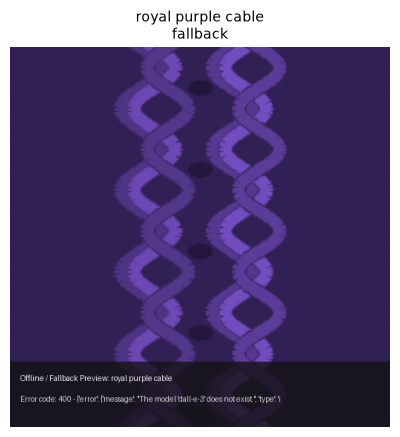

In [119]:
def _draw_v(draw: ImageDraw.ImageDraw, x: int, y: int, w: int, h: int, rgb: tuple[int, int, int], width: int) -> None:
    mid = x + w // 2
    draw.line([(x + 1, y + 2), (mid, y + h - 2)], fill=shade(rgb, 0.62), width=width)
    draw.line([(mid, y + h - 2), (x + w - 1, y + 2)], fill=shade(rgb, 1.22), width=width)


def _draw_purl_bump(draw: ImageDraw.ImageDraw, x: int, y: int, w: int, h: int, rgb: tuple[int, int, int]) -> None:
    pad = max(1, w // 8)
    draw.ellipse([x + pad, y + pad, x + w - pad, y + h - pad], fill=shade(rgb, 0.78), outline=shade(rgb, 0.55))
    draw.arc([x + pad, y + pad, x + w - pad, y + h - pad], 200, 40, fill=shade(rgb, 1.18), width=max(1, w // 10))


def _apply_fibre_finish(img: Image.Image, spec: SwatchSpec, rng: random.Random) -> Image.Image:
    fibre = spec.fibre_content.strip().lower()
    if "mohair" in fibre:
        img = img.filter(ImageFilter.GaussianBlur(radius=2.4))
        haze = Image.new("RGB", img.size, (255, 255, 255))
        img = Image.blend(img, haze, 0.14)
    elif "cotton" in fibre:
        img = ImageEnhance.Sharpness(img).enhance(1.7)
        img = ImageEnhance.Contrast(img).enhance(1.12)
    elif "alpaca" in fibre:
        img = img.filter(ImageFilter.GaussianBlur(radius=0.9))
        img = ImageEnhance.Brightness(img).enhance(1.05)
        img = ImageEnhance.Color(img).enhance(0.95)
    else:
        img = ImageEnhance.Contrast(img).enhance(1.06)
        pixels = img.load()
        w, h = img.size
        for _ in range((w * h) // 40):
            x = rng.randrange(w)
            y = rng.randrange(h)
            d = rng.randint(-7, 7)
            r, g, b = pixels[x, y]
            pixels[x, y] = clamp_rgb((r + d, g + d, b + d))
    if "cotton" not in fibre:
        img = img.filter(ImageFilter.SMOOTH)
    return img


def synthesize_stitch_texture(spec: SwatchSpec, size: int = 512) -> Image.Image:
    rgb = parse_hex(spec.colour_hex)
    scale = WEIGHT_SCALE.get(spec.weight_category.strip().lower().replace(" ", "_"), 1.0)
    stitch = spec.stitch_type.strip().lower()
    rng = random.Random(get_cache_key(spec))
    img = Image.new("RGB", (size, size), shade(rgb, 0.92))
    draw = ImageDraw.Draw(img)

    if stitch == "garter":
        row_h = max(8, int(14 * scale))
        for y in range(-row_h, size + row_h, row_h):
            ridge = shade(rgb, 1.18 if (y // row_h) % 2 == 0 else 0.72)
            valley = shade(rgb, 0.58)
            draw.rectangle([0, y, size, y + row_h], fill=ridge)
            draw.line([(0, y), (size, y)], fill=valley, width=max(2, int(3 * scale)))
            amp = max(2, int(3 * scale))
            pts = [(x, y + row_h // 2 + int(amp * math.sin(x / 9.0))) for x in range(0, size, 4)]
            if len(pts) > 1:
                draw.line(pts, fill=shade(rgb, 1.08), width=max(2, int(2 * scale)))
            for x in range(0, size, max(10, int(12 * scale))):
                _draw_purl_bump(draw, x, y, max(10, int(12 * scale)), row_h, rgb)

    elif stitch == "rib":
        col_w = max(8, int(11 * scale))
        row_h = max(10, int(14 * scale))
        pair = col_w * 2
        for x in range(0, size + pair, pair * 2):
            draw.rectangle([x, 0, x + pair - 1, size], fill=shade(rgb, 1.08))
            draw.rectangle([x + pair, 0, x + pair * 2 - 1, size], fill=shade(rgb, 0.62))
            draw.line([(x + pair, 0), (x + pair, size)], fill=shade(rgb, 0.42), width=max(2, int(3 * scale)))
            for yy in range(0, size, row_h):
                _draw_v(draw, x, yy, col_w, row_h, rgb, max(2, int(2 * scale)))
                _draw_v(draw, x + col_w, yy, col_w, row_h, rgb, max(2, int(2 * scale)))
            draw.line([(x, 0), (x, size)], fill=shade(rgb, 1.25), width=1)

    elif stitch == "seed":
        cell = max(10, int(16 * scale))
        for y in range(0, size + cell, cell):
            for x in range(0, size + cell, cell):
                knit = ((x // cell) + (y // cell)) % 2 == 0
                if knit:
                    draw.rectangle([x, y, x + cell, y + cell], fill=shade(rgb, 1.05))
                    _draw_v(draw, x, y, cell, cell, rgb, max(2, int(2 * scale)))
                else:
                    draw.rectangle([x, y, x + cell, y + cell], fill=shade(rgb, 0.82))
                    _draw_purl_bump(draw, x, y, cell, cell, rgb)

    elif stitch == "cable":
        img.paste(shade(rgb, 0.55), [0, 0, size, size])
        period = max(70, int(110 * scale))
        amp = max(18, int(28 * scale))
        thickness = max(10, int(16 * scale))
        for offset, phase, bright in ((-18, 0.0, 0.85), (0, 0.0, 1.15), (18, math.pi, 0.9)):
            pts_a = []
            pts_b = []
            for y in range(-20, size + 20, 3):
                wave = amp * math.sin((y / period) * math.pi * 2 + phase)
                xa = int(size * 0.38 + wave + offset)
                xb = int(size * 0.62 - wave + offset)
                pts_a.append((xa, y))
                pts_b.append((xb, y))
            draw.line(pts_a, fill=shade(rgb, bright * 0.75), width=thickness + 4)
            draw.line(pts_a, fill=shade(rgb, bright), width=thickness)
            draw.line(pts_b, fill=shade(rgb, bright * 0.7), width=thickness + 4)
            draw.line(pts_b, fill=shade(rgb, min(1.35, bright + 0.08)), width=thickness)
        for y in range(period // 2, size, period):
            draw.ellipse(
                [size // 2 - 16, y - 10, size // 2 + 16, y + 10],
                fill=shade(rgb, 0.4),
            )

    elif stitch == "lace":
        img.paste(shade(rgb, 1.02), [0, 0, size, size])
        cell = max(18, int(28 * scale))
        hole = max(5, int(8 * scale))
        for y in range(0, size + cell, cell):
            for x in range(0, size + cell, cell):
                cx = x + cell // 2
                cy = y + cell // 2
                diamond = [
                    (cx, y + 3),
                    (x + cell - 3, cy),
                    (cx, y + cell - 3),
                    (x + 3, cy),
                ]
                draw.polygon(diamond, outline=shade(rgb, 0.7))
                _draw_v(draw, x + cell // 4, y + cell // 4, cell // 2, cell // 2, rgb, 1)
                hx = hole + int(2 * math.sin((x + y) / 13.0))
                draw.ellipse([cx - hx, cy - hx, cx + hx, cy + hx], fill=shade(rgb, 0.28))
                draw.ellipse(
                    [cx - hx + 2, cy - hx + 2, cx + hx - 4, cy + hx - 4],
                    outline=shade(rgb, 1.2),
                )

    else:
        col_w = max(8, int(12 * scale))
        row_h = max(10, int(14 * scale))
        for y in range(-row_h, size + row_h, row_h):
            tint = 1.04 if (y // row_h) % 2 == 0 else 0.96
            draw.rectangle([0, y, size, y + row_h], fill=shade(rgb, tint))
            for x in range(-col_w, size + col_w, col_w):
                _draw_v(draw, x, y, col_w, row_h, rgb, max(2, int(2 * scale)))

    return _apply_fibre_finish(img, spec, rng)


def show_swatches(images: list[Image.Image], titles: list[str], figsize: Optional[tuple[float, float]] = None) -> None:
    n = max(1, len(images))
    fig, axes = plt.subplots(1, n, figsize=figsize or (4.1 * n, 4.6))
    if n == 1:
        axes = [axes]
    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


def _download_image(url: str, timeout: int = 60) -> Image.Image:
    response = requests.get(url, timeout=timeout)
    response.raise_for_status()
    return Image.open(io.BytesIO(response.content)).convert("RGB")


def _generate_openai_swatch(spec: SwatchSpec, prompt: str) -> Image.Image:
    client = OpenAI(api_key=OPENAI_API_KEY)
    result = client.images.generate(
        model="dall-e-3",
        prompt=prompt,
        size="1024x1024",
        quality="standard",
    )
    item = result.data[0]
    url = getattr(item, "url", None)
    b64 = getattr(item, "b64_json", None)
    if url:
        return _download_image(url)
    if b64:
        import base64

        return Image.open(io.BytesIO(base64.b64decode(b64))).convert("RGB")
    raise RuntimeError("OpenAI image response contained neither url nor b64_json")


def generate_swatch(spec: SwatchSpec, force_failure: bool = False) -> tuple[Image.Image, dict]:
    started = time.perf_counter()
    prompt = build_prompt(spec)
    key = get_cache_key(spec)
    meta = {
        "cached": False,
        "source": "fallback",
        "fallback": False,
        "latency_ms": 0.0,
        "prompt": prompt,
        "cache_key": key,
        "error": None,
    }

    try:
        if force_failure:
            raise ConnectionError("simulated provider outage (force_failure=True)")

        cached = load_cached(spec)
        if cached is not None:
            meta["cached"] = True
            meta["source"] = "cache"
            meta["latency_ms"] = (time.perf_counter() - started) * 1000.0
            return cached, meta

        if USE_OPENAI:
            image = _generate_openai_swatch(spec, prompt)
            meta["source"] = "openai"
        else:
            image = synthesize_stitch_texture(spec)
            meta["source"] = "procedural"

        save_cached(spec, image)
        meta["latency_ms"] = (time.perf_counter() - started) * 1000.0
        return image, meta
    except Exception as exc:
        image = generate_fallback_swatch(spec, str(exc))
        meta["source"] = "fallback"
        meta["fallback"] = True
        meta["error"] = str(exc)
        if not force_failure:
            save_cached(spec, image)
        meta["latency_ms"] = (time.perf_counter() - started) * 1000.0
        return image, meta


sample_img, sample_meta = generate_swatch(demo_spec)
print(
    {k: sample_meta[k] for k in ("source", "cached", "fallback", "latency_ms", "cache_key", "error")}
)
show_swatches([sample_img], [f"{demo_spec.colour_name} {demo_spec.stitch_type}\n{sample_meta['source']}"])


## Cell 5 — Ravelry API reference fetcher

Query `patterns/search.json` with HTTP Basic Auth. Missing credentials, timeouts, and empty photo results return `None` with a printed reason — never an uncaught exception.


In [120]:
def fetch_ravelry_reference(stitch_name: str) -> Optional[Image.Image]:
    if not RAVELRY_ACCESS_KEY or not RAVELRY_PERSONAL_KEY:
        print("Ravelry skipped: RAVELRY_ACCESS_KEY / RAVELRY_PERSONAL_KEY are not set.")
        return None
    url = (
        "https://api.ravelry.com/patterns/search.json"
        f"?query={quote_plus(stitch_name)}&photo=yes&page_size=1"
    )
    try:
        response = requests.get(
            url,
            auth=(RAVELRY_ACCESS_KEY, RAVELRY_PERSONAL_KEY),
            timeout=20,
            headers={"User-Agent": "assignment-b-swatch-preview/1.0"},
        )
    except requests.RequestException as exc:
        print(f"Ravelry skipped: network error ({exc}).")
        return None

    if response.status_code != 200:
        print(f"Ravelry skipped: HTTP {response.status_code}.")
        return None

    try:
        payload = response.json()
    except ValueError:
        print("Ravelry skipped: response was not JSON.")
        return None

    patterns = payload.get("patterns") or []
    if not patterns:
        print(f"Ravelry skipped: no patterns matched {stitch_name!r}.")
        return None

    photo = patterns[0].get("first_photo") or {}
    photo_url = photo.get("medium_url") or photo.get("medium2_url") or photo.get("small_url")
    if not photo_url:
        print("Ravelry skipped: matched pattern has no downloadable photo URL.")
        return None

    try:
        image = _download_image(photo_url, timeout=20)
    except Exception as exc:
        print(f"Ravelry skipped: photo download failed ({exc}).")
        return None

    name = patterns[0].get("name") or stitch_name
    print(f"Ravelry reference: {name}")
    return image


_ = fetch_ravelry_reference("cable")


Ravelry reference: Eirena Sweater


## Cell 6 — Fast color switching (requirement 4.4)

Same cable / worsted / wool structure, three hex colors. Latency per swatch is the number that would stall a mobile knit-preview flow.


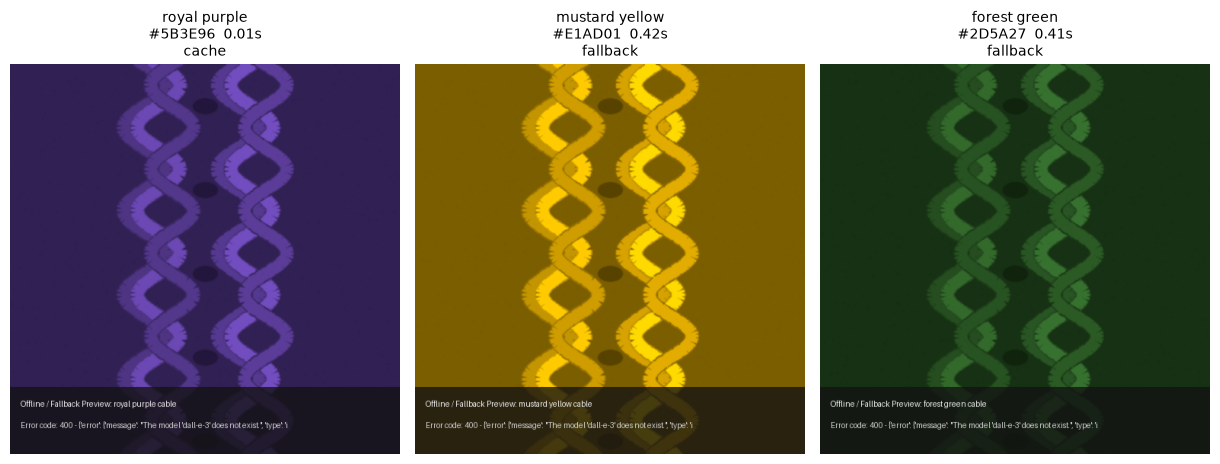

Color-switch latencies (ms): [11.52, 422.95, 408.37]
Engineering note: generative inference at 3-5 seconds per swatch breaks interactive flow on a mobile yarn app - shoppers expect color chips to update immediately while scrubbing a palette. Prefetch a small stitch atlas, then recolor on-device with a multiply/overlay tint (Cell 10). Keep full DALL-E (or equivalent) for first-time structure generation, not for every hex change.


In [121]:
COLOR_CASES = [
    {"name": "royal purple", "hex": "#5B3E96"},
    {"name": "mustard yellow", "hex": "#E1AD01"},
    {"name": "forest green", "hex": "#2D5A27"},
]

color_images = []
color_titles = []
color_latencies = []
for case in COLOR_CASES:
    spec = SwatchSpec("cable", case["name"], case["hex"], "worsted", "100% wool")
    image, meta = generate_swatch(spec)
    seconds = meta["latency_ms"] / 1000.0
    color_images.append(image)
    color_latencies.append(meta["latency_ms"])
    color_titles.append(f"{case['name']}\n{case['hex']}  {seconds:.2f}s\n{meta['source']}")

show_swatches(color_images, color_titles)

print("Color-switch latencies (ms):", [round(ms, 2) for ms in color_latencies])
print(
    "Engineering note: generative inference at 3-5 seconds per swatch breaks interactive "
    "flow on a mobile yarn app - shoppers expect color chips to update immediately while "
    "scrubbing a palette. Prefetch a small stitch atlas, then recolor on-device with a "
    "multiply/overlay tint (Cell 10). Keep full DALL-E (or equivalent) for first-time "
    "structure generation, not for every hex change."
)


## Cell 7 — Structural variation (requirement 4.4)

Same terracotta worsted wool, three stitch families. The preview is only useful if cables, ribs, and stockinette are geometrically distinct.


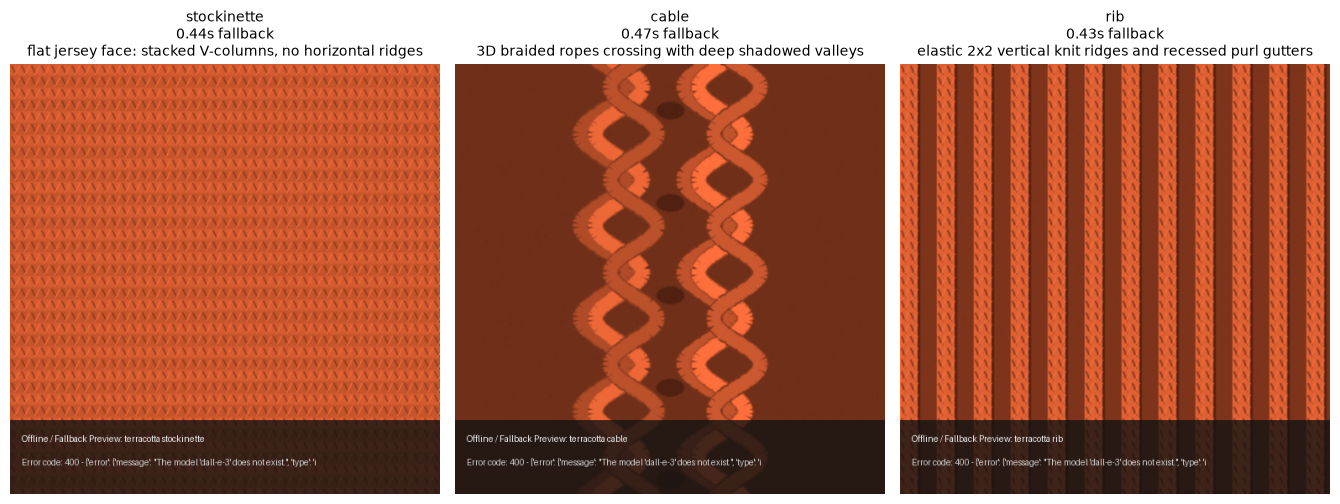

Visual check: V-columns vs rope twists vs vertical accordion ribs should be obvious at a glance.


In [122]:
STRUCTURE_NOTES = {
    "stockinette": "flat jersey face: stacked V-columns, no horizontal ridges",
    "cable": "3D braided ropes crossing with deep shadowed valleys",
    "rib": "elastic 2x2 vertical knit ridges and recessed purl gutters",
}

structure_images = []
structure_titles = []
for stitch in ("stockinette", "cable", "rib"):
    spec = SwatchSpec(stitch, "terracotta", "#C85A32", "worsted", "100% wool")
    image, meta = generate_swatch(spec)
    structure_images.append(image)
    structure_titles.append(
        f"{stitch}\n{meta['latency_ms']/1000:.2f}s {meta['source']}\n{STRUCTURE_NOTES[stitch]}"
    )

show_swatches(structure_images, structure_titles, figsize=(13.5, 5.2))
print("Visual check: V-columns vs rope twists vs vertical accordion ribs should be obvious at a glance.")


## Cell 8 — Cache hit and resilient fallback proofs

Call 1 is a miss (fresh sage seed spec). Call 2 must be a disk hit. `force_failure=True` bypasses cache so the badge path is actually exercised.


Call 1 miss: cached=False source=fallback 481.36 ms
Call 2 hit:  cached=True source=cache 7.37 ms
Call 3 fallback: cached=False source=fallback fallback=True error='simulated provider outage (force_failure=True)' 33.41 ms


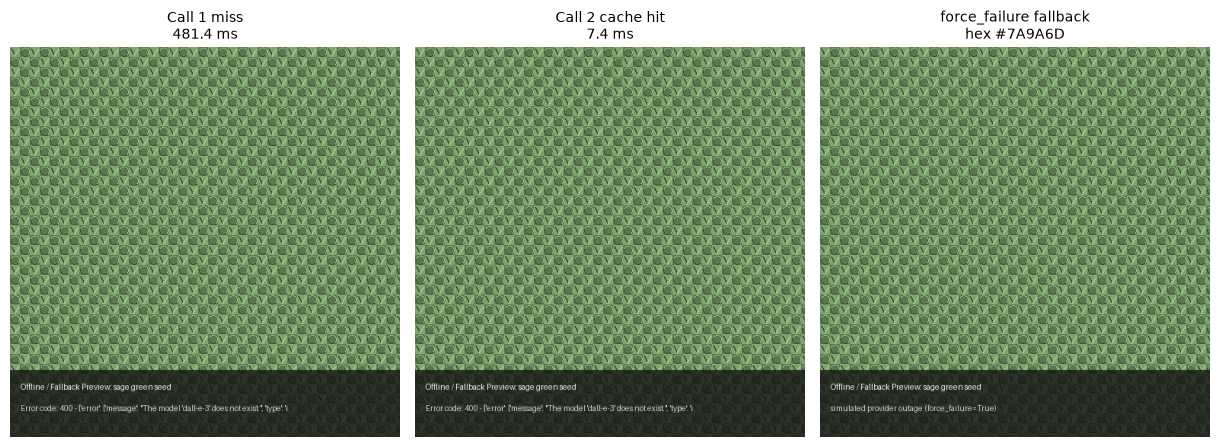

Notebook continued after force_failure: no crash.


In [123]:
proof_spec = SwatchSpec("seed", "sage green", "#7A9A6D", "dk", "100% cotton")
proof_path = cache_path(proof_spec)
if proof_path.exists():
    proof_path.unlink()

miss_img, miss_meta = generate_swatch(proof_spec)
hit_img, hit_meta = generate_swatch(proof_spec)
fail_img, fail_meta = generate_swatch(proof_spec, force_failure=True)

print(
    f"Call 1 miss: cached={miss_meta['cached']} source={miss_meta['source']} "
    f"{miss_meta['latency_ms']:.2f} ms"
)
print(
    f"Call 2 hit:  cached={hit_meta['cached']} source={hit_meta['source']} "
    f"{hit_meta['latency_ms']:.2f} ms"
)
print(
    f"Call 3 fallback: cached={fail_meta['cached']} source={fail_meta['source']} "
    f"fallback={fail_meta['fallback']} error={fail_meta['error']!r} "
    f"{fail_meta['latency_ms']:.2f} ms"
)

assert miss_meta["cached"] is False
assert hit_meta["cached"] is True
assert hit_meta["latency_ms"] < miss_meta["latency_ms"]
assert fail_meta["fallback"] is True
assert fail_meta["cached"] is False

show_swatches(
    [miss_img, hit_img, fail_img],
    [
        f"Call 1 miss\n{miss_meta['latency_ms']:.1f} ms",
        f"Call 2 cache hit\n{hit_meta['latency_ms']:.1f} ms",
        f"force_failure fallback\nhex {proof_spec.colour_hex}",
    ],
)
print("Notebook continued after force_failure: no crash.")


## Cell 9 — Real Ravelry pattern comparison

AI (or procedural) cable swatch beside a live Ravelry thumbnail when credentials work. If they do not, the generated swatch still displays alone.


Ravelry reference: Eirena Sweater


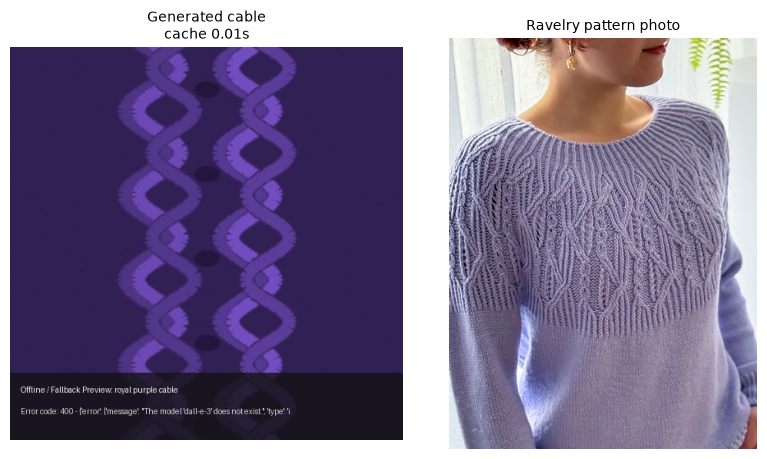

In [124]:
ravelry_spec = SwatchSpec("cable", "royal purple", "#5B3E96", "worsted", "100% wool")
ai_cable, ai_meta = generate_swatch(ravelry_spec)
ravelry_photo = fetch_ravelry_reference("cable")

if ravelry_photo is not None:
    show_swatches(
        [ai_cable, ravelry_photo],
        [
            f"Generated cable\n{ai_meta['source']} {ai_meta['latency_ms']/1000:.2f}s",
            "Ravelry pattern photo",
        ],
    )
else:
    print("Displaying generated cable swatch only.")
    show_swatches([ai_cable], [f"Generated cable ({ai_meta['source']}) — Ravelry unavailable"])


## Cell 10 — Color tinting / image-processing alternative

Generate one neutral stitch atlas, then recolor with `ImageChops.multiply`. This is the client-side path that keeps palette scrubbing under 20 ms, at the cost of some yarn luster.


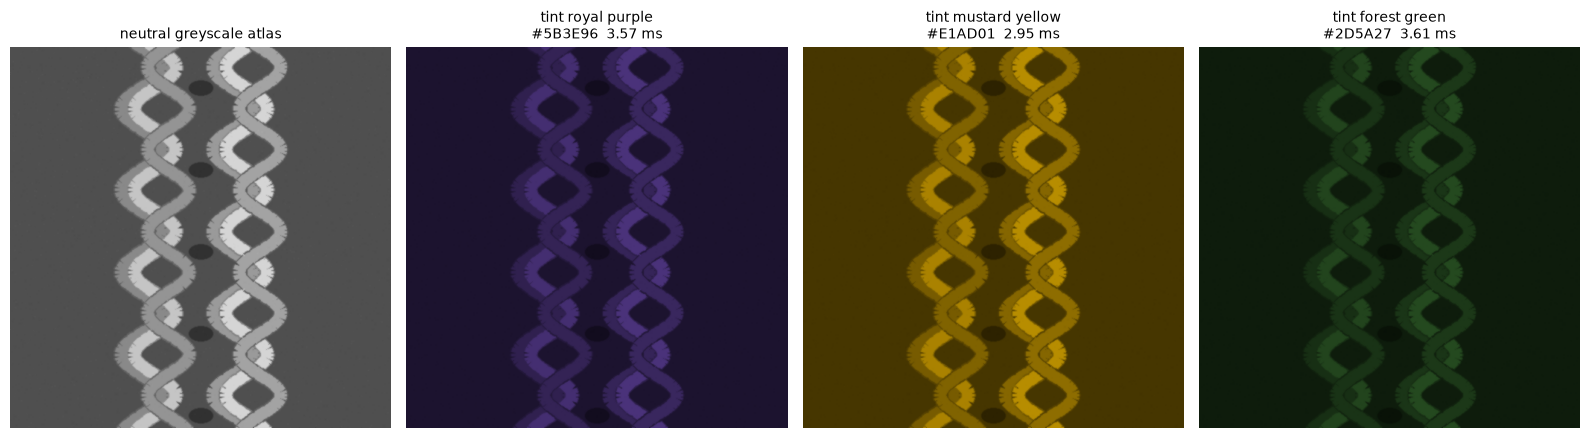

Tint latencies (ms): [3.572, 2.951, 3.611]
Generative/procedural latencies from Cell 6 (ms): [11.52, 422.95, 408.37]
Speedup vs Cell 6 mean: 83x (tint mean 3.38 ms vs gen mean 280.9 ms).
Trade-off: multiply tinting is fast enough for live palette scrubbing (<20 ms typical) but flattens photorealistic yarn luster, heather, and color-dependent shadow warmth. Use tinting for interaction; reserve a full generative (or high-quality procedural) pass when the stitch structure itself changes.


In [125]:
def apply_color_tint(base_image: Image.Image, target_hex: str) -> Image.Image:
    gray = ImageEnhance.Contrast(base_image.convert("L")).enhance(1.15)
    gray_rgb = gray.convert("RGB")
    color_layer = Image.new("RGB", gray_rgb.size, parse_hex(target_hex))
    return ImageChops.multiply(gray_rgb, color_layer)


neutral_spec = SwatchSpec("cable", "neutral greige", "#9A9A9A", "worsted", "100% wool")
neutral_base = synthesize_stitch_texture(neutral_spec)
neutral_l = ImageEnhance.Contrast(neutral_base.convert("L")).enhance(1.2).convert("RGB")

tint_images = [neutral_l]
tint_titles = ["neutral greyscale atlas"]
tint_ms = []
for case in COLOR_CASES:
    started = time.perf_counter()
    tinted = apply_color_tint(neutral_base, case["hex"])
    elapsed = (time.perf_counter() - started) * 1000.0
    tint_ms.append(elapsed)
    tint_images.append(tinted)
    tint_titles.append(f"tint {case['name']}\n{case['hex']}  {elapsed:.2f} ms")

show_swatches(tint_images, tint_titles, figsize=(16, 4.4))

gen_ms = color_latencies
print("Tint latencies (ms):", [round(ms, 3) for ms in tint_ms])
print("Generative/procedural latencies from Cell 6 (ms):", [round(ms, 2) for ms in gen_ms])
print(
    f"Speedup vs Cell 6 mean: "
    f"{(sum(gen_ms) / len(gen_ms)) / max(sum(tint_ms) / len(tint_ms), 1e-6):.0f}x "
    f"(tint mean {sum(tint_ms)/len(tint_ms):.2f} ms vs gen mean {sum(gen_ms)/len(gen_ms):.1f} ms)."
)
print(
    "Trade-off: multiply tinting is fast enough for live palette scrubbing (<20 ms typical) "
    "but flattens photorealistic yarn luster, heather, and color-dependent shadow warmth. "
    "Use tinting for interaction; reserve a full generative (or high-quality procedural) "
    "pass when the stitch structure itself changes."
)
